# Evaluasi dan Analisis Pengalaman Pengguna Aplikasi Trima+ (PT Trimegah Sekuritas Indonesia Tbk)
### Business Case Competition & Customer Experience Deep-Dive

**Tujuan Notebook:**
1. **Scraping & Analisis Kepuasan:** Menganalisis 1.312 ulasan publik Google Play Store aplikasi Trima+ (`com.trimegah.trima`).
2. **Normalisasi Skor Objektif:** Menerapkan standardisasi skala 0–1 dan 0–100 tanpa mendistorsi tingginya proporsi bintang 5 sebagai temuan otentik.
3. **Root Cause Analysis Mendalam:** Membedah **seluruh kategori keluhan** nasabah (Login, UI/UX, Transaksi Saham, Stabilitas/Bug, KYC, CS, hingga Fitur Analisis) agar dapat dianalisis mandiri secara transparan.
4. **Rekomendasi Bisnis Strategis:** Menyajikan visualisasi terpadu dan solusi bisnis yang terukur untuk bahan presentasi kompetisi bisnis.

## 1. Persiapan Pustaka & Memuat Dataset Ulasan Bersih
Memuat pustaka utama (`pandas`, `numpy`, `matplotlib`) dan membaca dataset ulasan Trima+ yang telah disanitasi dari informasi pribadi nasabah sesuai regulasi privasi data (UU PDP No. 27/2022).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.autolayout'] = True

# Konfigurasi pandas agar teks ulasan panjang dapat dibaca utuh
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)

# Memuat dataset ulasan yang telah dibersihkan
data_path = os.path.join("output", "trima_reviews_clean.csv")
df = pd.read_csv(data_path)

print(f"[SUCCESS] Dataset berhasil dimuat!")
print(f"Total baris ulasan unik: {len(df):,}")
print(f"Distribusi Topik Utama:")
display(df['primary_topic'].value_counts().to_frame('Jumlah Ulasan'))

[SUCCESS] Dataset berhasil dimuat!
Total baris ulasan unik: 1,312
Distribusi Topik Utama:


primary_topic,Jumlah Ulasan
Apresiasi Umum & Kepuasan,714
Login & Autentikasi,143
Keluhan Umum Aplikasi,121
UI/UX & Performa (Loading/Navigasi),104
Transaksi & Portofolio Saham,66
Customer Service & Layanan,46
Netral / Saran Umum,37
Stabilitas Sistem & Bug (Crash/Error),36
Registrasi & Onboarding (KYC),29
Fitur Analisis & Data Pasar,16


## 2. Verifikasi Data & Metrik Kunci (Executive Overview)
Membedakan metrik agregat yang ditampilkan di halaman publik toko aplikasi dengan jumlah sampel ulasan bertulis yang sebenarnya dianalisis untuk mencegah bias interpretasi di hadapan dewan juri.

In [2]:
total_reviews = len(df)
avg_stars = df['stars'].mean()
med_stars = df['stars'].median()
norm_0_1 = df['normalized_score_0_1'].mean()
norm_0_100 = df['normalized_score_0_100'].mean()

b12 = (df['stars'] <= 2).sum()
b3 = (df['stars'] == 3).sum()
b45 = (df['stars'] >= 4).sum()

summary_metrics = pd.DataFrame([
    {"Indikator Metrik Bisnis": "Total Rating Publik Google Play", "Nilai Temuan": "3,747 rating", "Keterangan & Konteks Bisnis": "Angka akumulatif di Play Store"},
    {"Indikator Metrik Bisnis": "Estimasi Ulasan Ditampilkan", "Nilai Temuan": "1,775 ulasan", "Keterangan & Konteks Bisnis": "Ulasan terdeteksi Google (termasuk tanpa teks)"},
    {"Indikator Metrik Bisnis": "Sampel Review Bertulis Dianalisis (N)", "Nilai Temuan": f"{total_reviews:,} ulasan", "Keterangan & Konteks Bisnis": "100% ulasan bertulis publik yang diekstrak"},
    {"Indikator Metrik Bisnis": "Rata-rata Rating Resmi Play Store", "Nilai Temuan": "3.12 / 5.0", "Keterangan & Konteks Bisnis": "Rata-rata seluruh rating Play Store"},
    {"Indikator Metrik Bisnis": "Rata-rata Rating Review Bertulis", "Nilai Temuan": f"{avg_stars:.2f} / 5.0", "Keterangan & Konteks Bisnis": "Rata-rata khusus nasabah yang menulis feedback"},
    {"Indikator Metrik Bisnis": "Median Rating", "Nilai Temuan": f"{med_stars:.1f} / 5.0", "Keterangan & Konteks Bisnis": "Nilai tengah distribusi kepuasan"},
    {"Indikator Metrik Bisnis": "Skor Normalisasi (0.00 – 1.00)", "Nilai Temuan": f"{norm_0_1:.4f}", "Keterangan & Konteks Bisnis": "Rumus: (stars - 1) / 4"},
    {"Indikator Metrik Bisnis": "Skor Normalisasi (0 – 100)", "Nilai Temuan": f"{norm_0_100:.1f} / 100", "Keterangan & Konteks Bisnis": "Rumus: (stars - 1) * 25"},
    {"Indikator Metrik Bisnis": "Positive Share (Bintang 4–5)", "Nilai Temuan": f"{b45/total_reviews*100:.1f}% ({b45:,})", "Keterangan & Konteks Bisnis": "Nasabah sangat puas & loyal"},
    {"Indikator Metrik Bisnis": "Neutral Share (Bintang 3)", "Nilai Temuan": f"{b3/total_reviews*100:.1f}% ({b3:,})", "Keterangan & Konteks Bisnis": "Nasabah dengan friksi ringan"},
    {"Indikator Metrik Bisnis": "Negative Share (Bintang 1–2)", "Nilai Temuan": f"{b12/total_reviews*100:.1f}% ({b12:,})", "Keterangan & Konteks Bisnis": "Area friksi kritis / churn risk"},
    {"Indikator Metrik Bisnis": "Developer Response Rate", "Nilai Temuan": f"{(df['has_developer_reply'] == 'Ya').mean()*100:.1f}%", "Keterangan & Konteks Bisnis": "Respon CS pengembang terhadap ulasan"}
])
summary_metrics

Indikator Metrik Bisnis,Nilai Temuan,Keterangan & Konteks Bisnis
Total Rating Publik Google Play,"3,747 rating",Angka akumulatif di Play Store
Estimasi Ulasan Ditampilkan,"1,775 ulasan",Ulasan terdeteksi Google (termasuk tanpa teks)
Sampel Review Bertulis Dianalisis (N),"1,312 ulasan",100% ulasan bertulis publik yang diekstrak
Rata-rata Rating Resmi Play Store,3.12 / 5.0,Rata-rata seluruh rating Play Store
Rata-rata Rating Review Bertulis,3.68 / 5.0,Rata-rata khusus nasabah yang menulis feedback
Median Rating,5.0 / 5.0,Nilai tengah distribusi kepuasan
Skor Normalisasi (0.00 – 1.00),0.6709,Rumus: (stars - 1) / 4
Skor Normalisasi (0 – 100),67.1 / 100,Rumus: (stars - 1) * 25
Positive Share (Bintang 4–5),62.9% (825),Nasabah sangat puas & loyal
Neutral Share (Bintang 3),8.8% (115),Nasabah dengan friksi ringan


## 3. Distribusi Rating Bintang Asli vs Skor Ternormalisasi
**Prinsip Normalisasi:** Bintang asli tetap disimpan. Normalisasi dilakukan untuk keperluan perbandingan analitis.
- **Bintang 5 (55.3%) tetap dipertahankan sebagai temuan objektif**, bukan dipotong atau diratakan secara artifisial.
- Skala 0–1: `normalized_score = (stars - 1) / 4`
- Skala 0–100: `normalized_score_100 = (stars - 1) * 25`

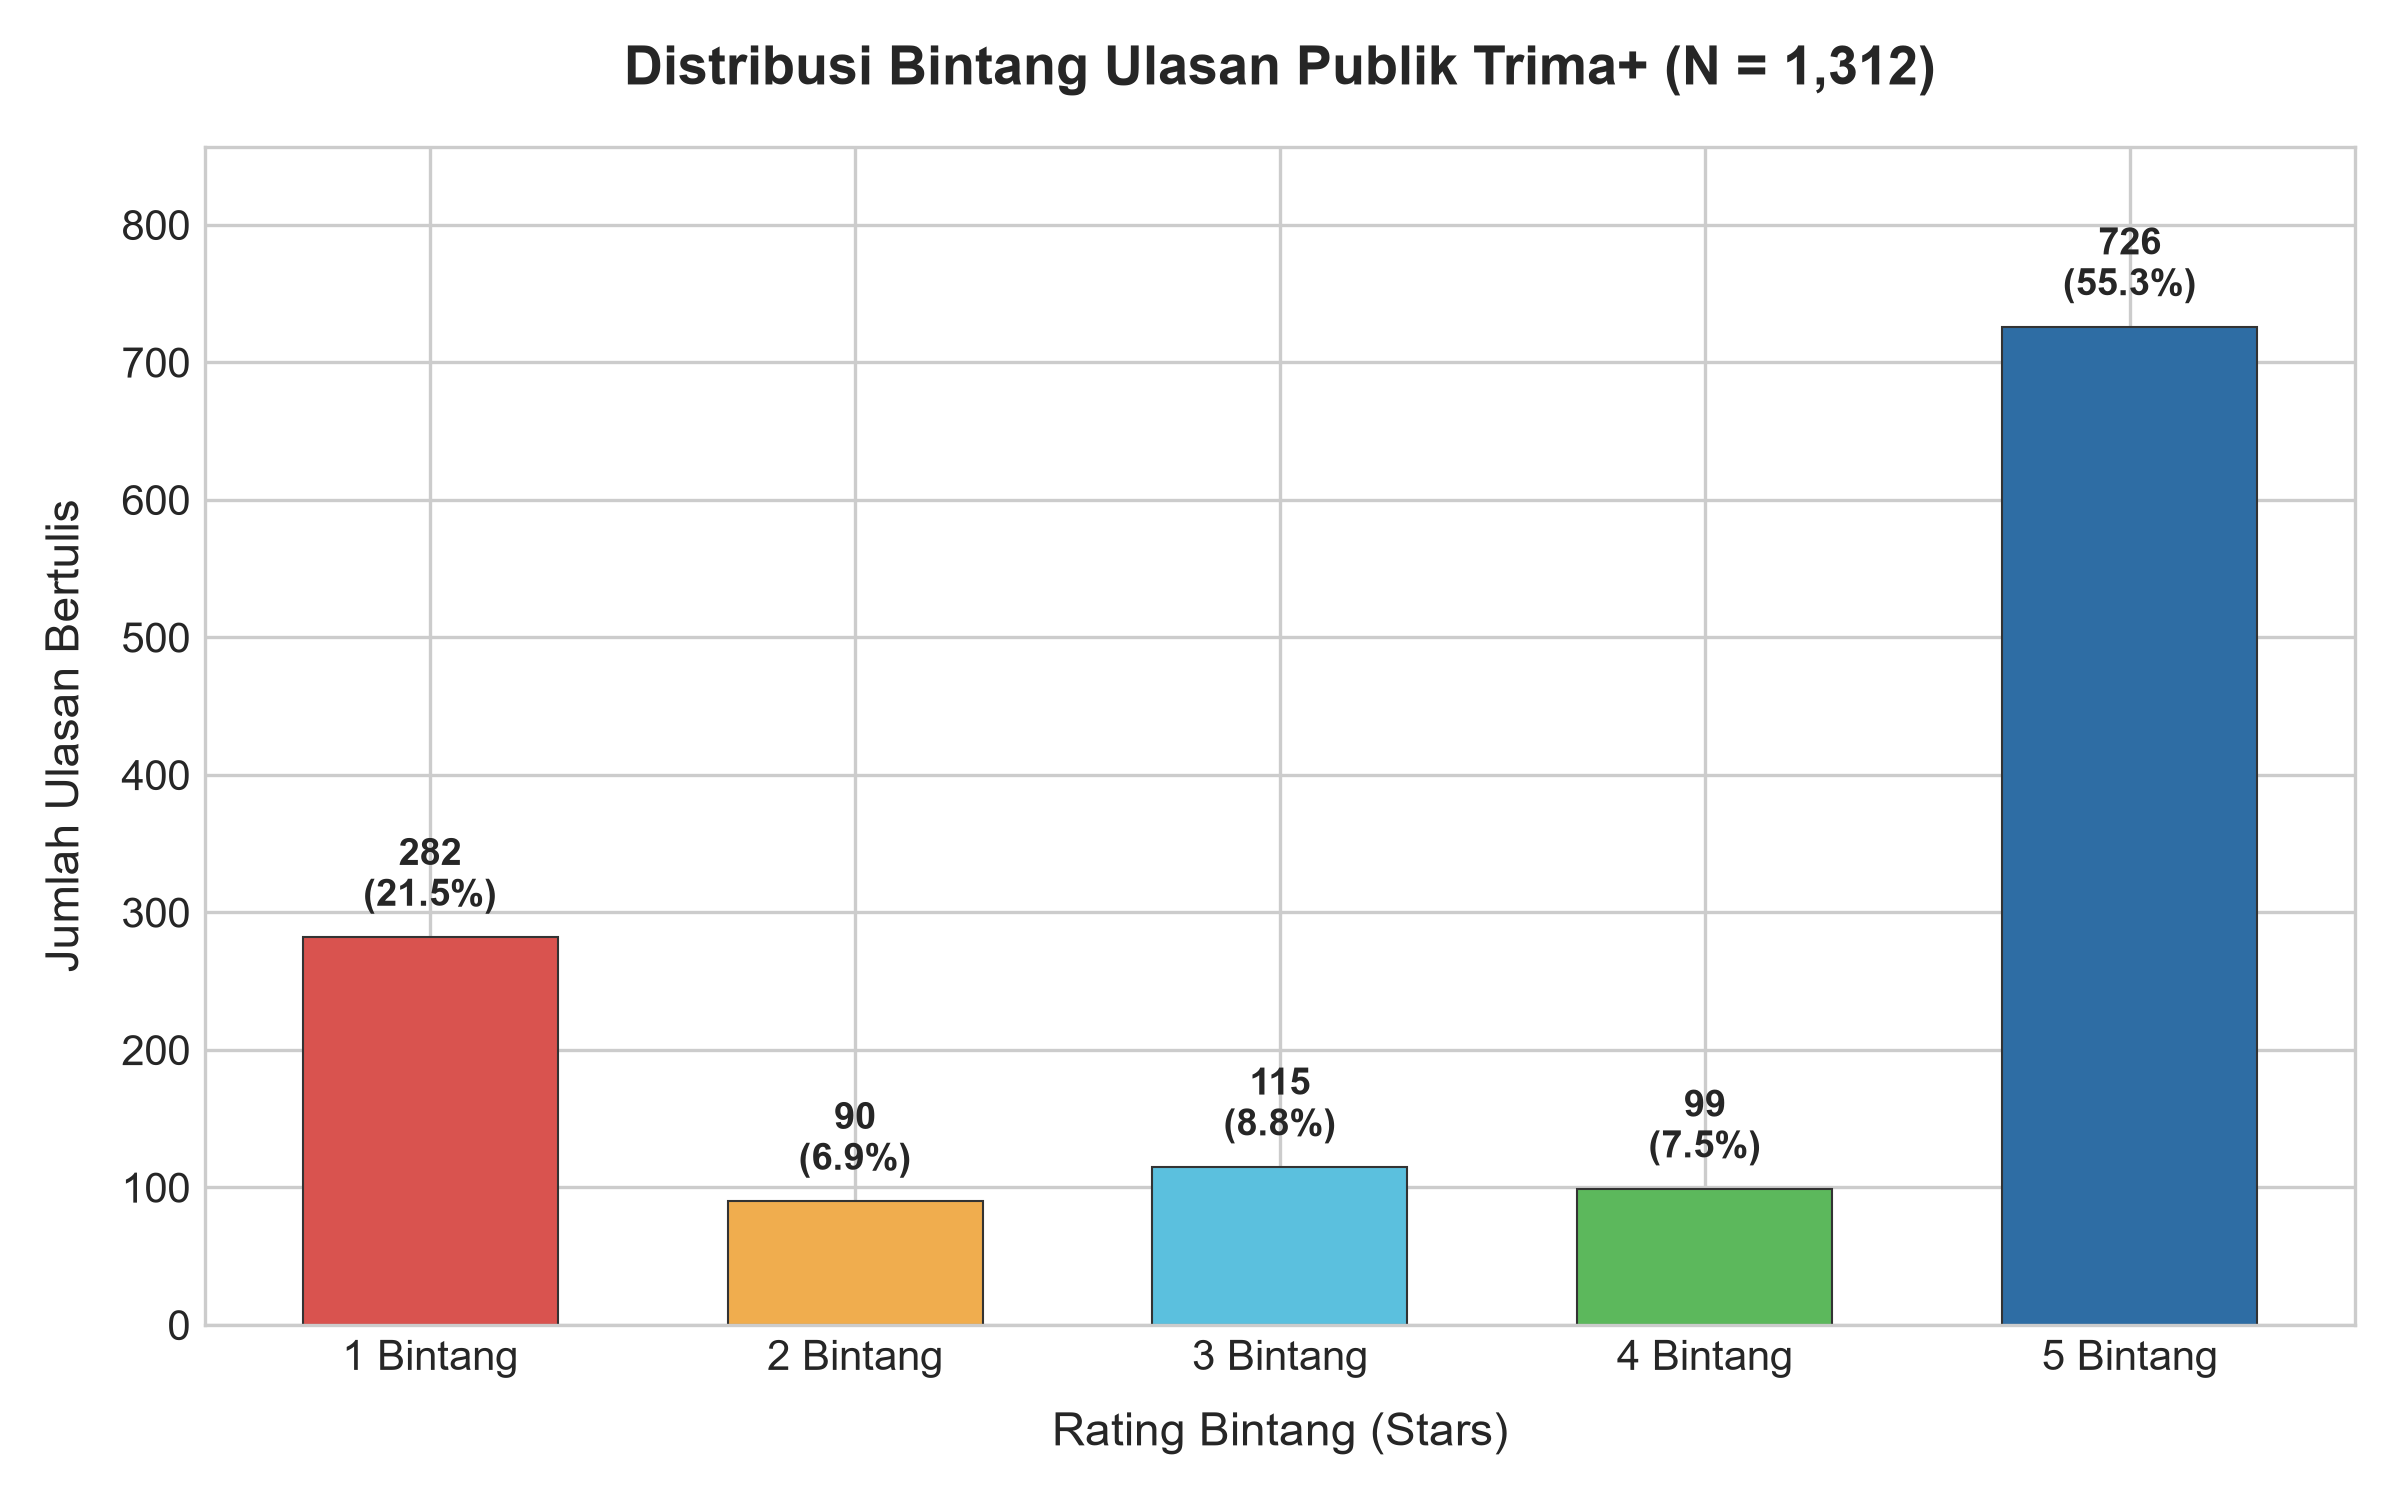

In [3]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
star_counts = df['stars'].value_counts().sort_index()
star_pct = (star_counts / len(df) * 100)

colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#2e6da4']
bars = ax.bar(star_counts.index, star_counts.values, color=colors, width=0.6, edgecolor='#333333', linewidth=0.5)

for bar, pct, cnt in zip(bars, star_pct.values, star_counts.values):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 15, f"{cnt:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
    
ax.set_title(f"Distribusi Bintang Ulasan Publik Trima+ (N = {len(df):,})", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Rating Bintang (Stars)", fontsize=11, labelpad=8)
ax.set_ylabel("Jumlah Ulasan Bertulis", fontsize=11, labelpad=8)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1 Bintang", "2 Bintang", "3 Bintang", "4 Bintang", "5 Bintang"], fontsize=10)
ax.set_ylim(0, max(star_counts.values) * 1.18)
plt.show()

## 4. Analisis Proporsi Sentimen Pengguna
Pengelompokan ulasan ke dalam tiga zona sentimen:
- **Positive Share (Bintang 4–5):** 62.9% (825 ulasan)
- **Neutral Share (Bintang 3):** 8.8% (115 ulasan)
- **Negative Share (Bintang 1–2):** 28.4% (372 ulasan)

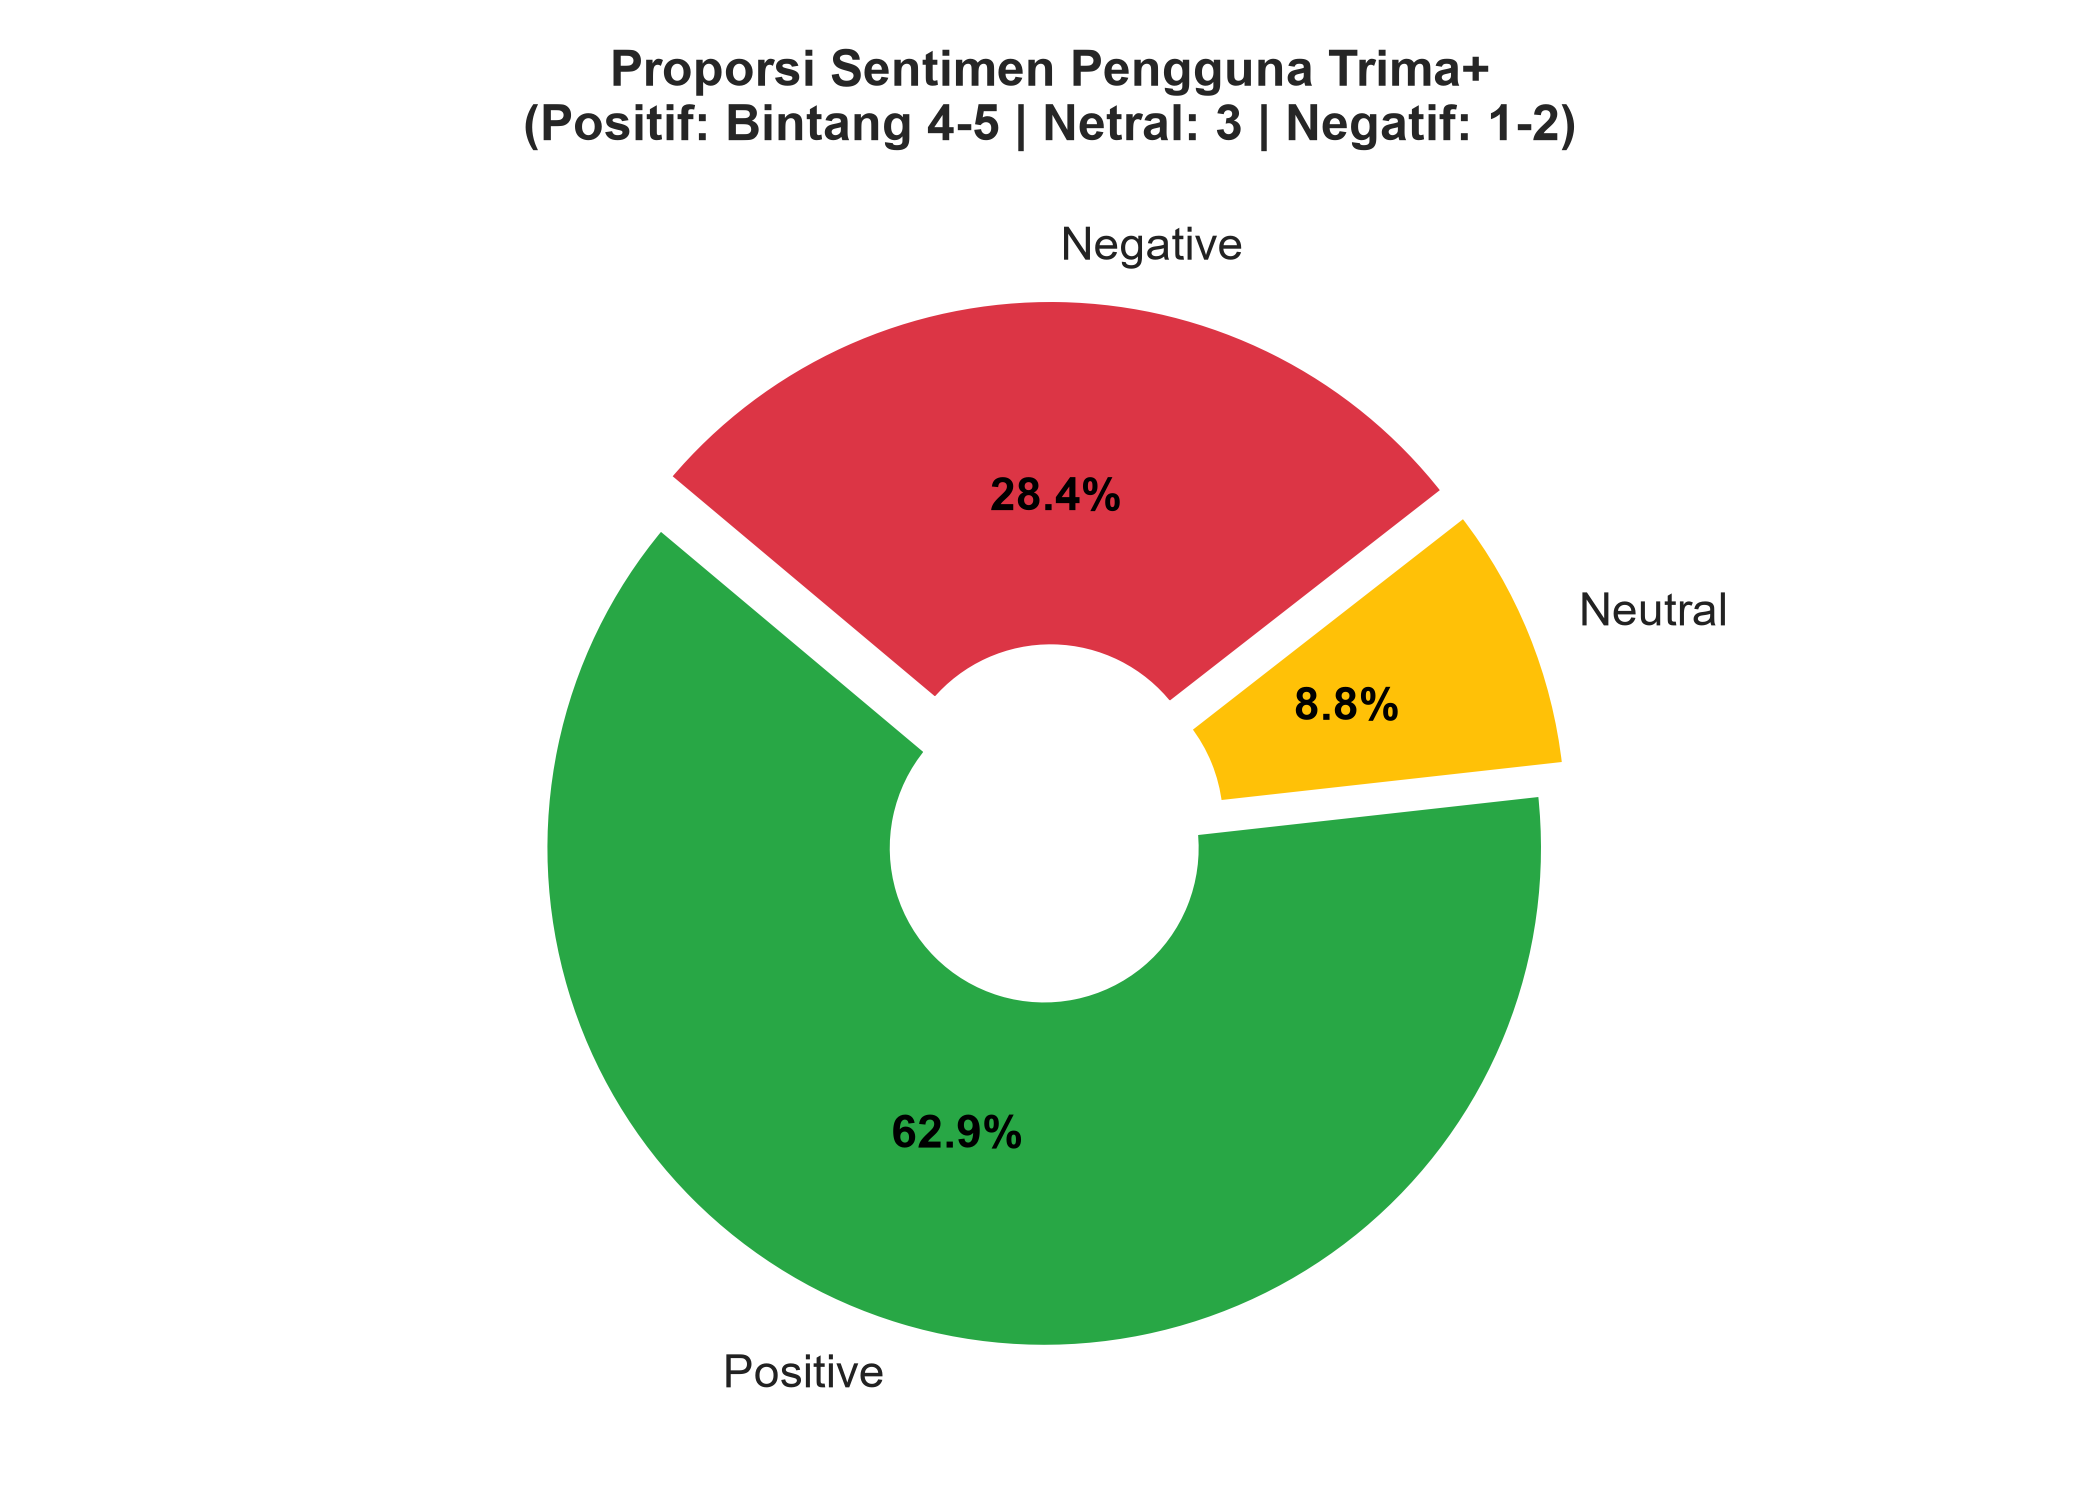

In [4]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sent_counts = df['sentiment'].value_counts()[['Positive', 'Neutral', 'Negative']]
sent_colors = ['#28a745', '#ffc107', '#dc3545']

wedges, texts, autotexts = ax.pie(
    sent_counts, 
    labels=sent_counts.index, 
    autopct='%1.1f%%',
    startangle=140, 
    colors=sent_colors,
    explode=(0.04, 0.04, 0.06),
    textprops=dict(color="#222222", fontsize=11),
    wedgeprops=dict(width=0.7, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_color('black')
    at.set_fontweight('bold')
    
ax.set_title("Proporsi Sentimen Pengguna Trima+\n(Positif: Bintang 4-5 | Netral: 3 | Negatif: 1-2)", fontsize=12, fontweight='bold', pad=15)
plt.show()

## 5. Root Cause Analysis: Pemetaan Masalah Ulasan Negatif (Bintang 1–2)
Sebanyak **372 nasabah** memberikan rating bintang 1 dan 2. Berikut perbandingan distribusi frekuensi masalah teknis dan operasional yang dihadapi nasabah.

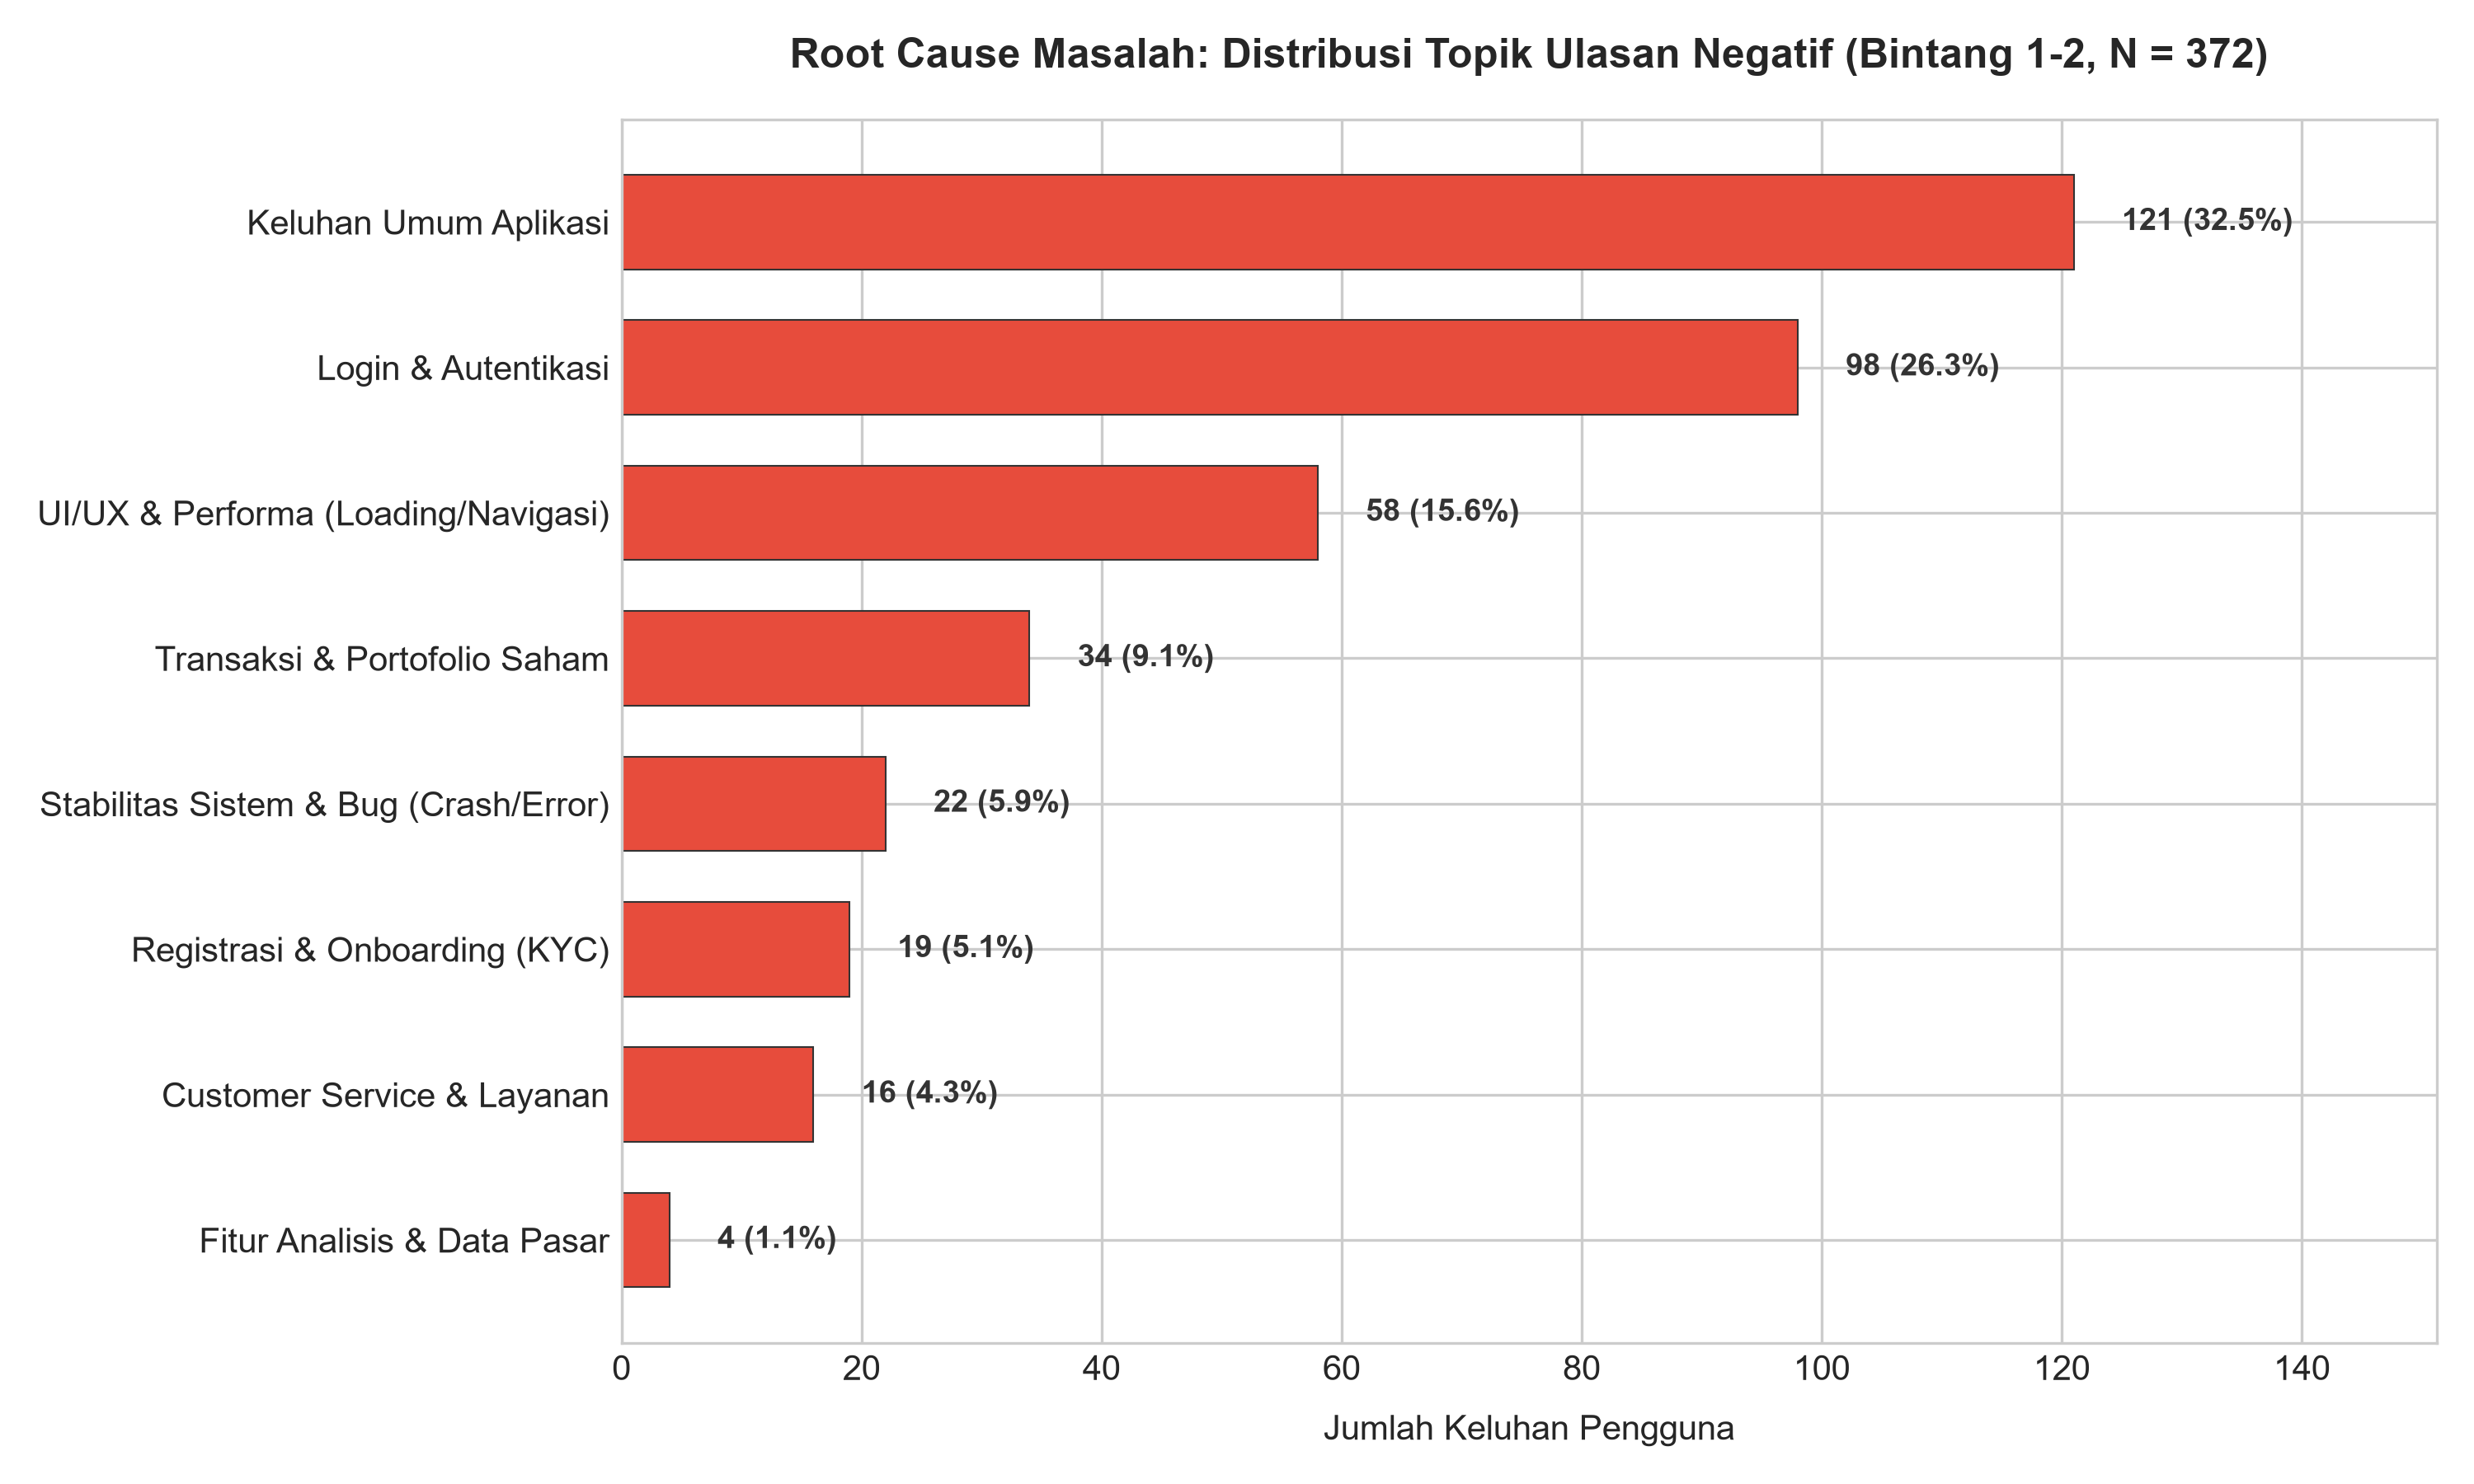

In [5]:
neg_df = df[df['stars'] <= 2].copy()
topic_counts = neg_df['primary_topic'].value_counts().reset_index()
topic_counts.columns = ['Topik Keluhan', 'Jumlah Keluhan']
topic_counts['Persentase (%)'] = (topic_counts['Jumlah Keluhan'] / len(neg_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
y_pos = np.arange(len(topic_counts))
bars = ax.barh(y_pos, topic_counts['Jumlah Keluhan'], color='#e74c3c', edgecolor='#333333', linewidth=0.5, height=0.65)
ax.set_yticks(y_pos)
ax.set_yticklabels(topic_counts['Topik Keluhan'], fontsize=10)
ax.invert_yaxis()

for bar, val, pct in zip(bars, topic_counts['Jumlah Keluhan'], topic_counts['Persentase (%)']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2.0, f"{val} ({pct:.1f}%)", va='center', fontsize=9, fontweight='bold', color='#333333')
    
ax.set_title(f"Root Cause Masalah: Distribusi Topik Ulasan Negatif (Bintang 1-2, N = {len(neg_df):,})", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Jumlah Keluhan Pengguna", fontsize=10, labelpad=8)
ax.set_xlim(0, max(topic_counts['Jumlah Keluhan']) * 1.25)
plt.show()

topic_counts

--- 
# 6. Deep-Dive Eksplorasi Detail Setiap Kategori Masalah
Di bawah ini disediakan sel inspeksi khusus untuk **setiap kategori ulasan**, agar Anda dapat membaca teks ulasan nasabah secara utuh, melihat nomor versi aplikasi yang bermasalah, serta menganalisis balasan dari tim *Customer Service / Developer*.

### 6.1 Kategori: Keluhan Umum Aplikasi (121 Ulasan)
Kategori ini mencakup ulasan pengguna yang mengekspresikan ketidakpuasan tinggi atau kendala umum tanpa menyebut modul transaksi tertentu (misal: 'aplikasi tidak bisa dibuka', 'kecewa berat', 'parah', kendala saldo mengendap).

In [6]:
# Tampilkan ulasan 'Keluhan Umum Aplikasi'
topic_name = 'Keluhan Umum Aplikasi'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Keluhan Umum Aplikasi'
Total: 121 ulasan (9.2% dari seluruh ulasan)
Distribusi Bintang: {1: 95, 2: 26}
Persentase Dibalas Developer: 36.4%

[1] Rating: ⭐ (1/5) | Tanggal: 2024-11-22 22:17:34 | Versi App: 2.8.3
    Ulasan Nasabah : "Ini knp malah g bs dbuka samsek?"
    Balasan CS/Dev : "Terima kasih telah menginstall Aplikasi Trima, silahkan untuk mengupdate ke versi 2.2.1, untuk kritik dan saran dapat Anda sampaikan ke customer service kami di +62 21 2924 9000."
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2024-11-14 19:47:23 | Versi App: 2.12.0
    Ulasan Nasabah : "Kok setelah di upgrade, malah gk bisa dibuka?"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2024-11-11 10:06:25 | Versi App: 2.12.0
    Ulasan Nasabah : "Ini kenapa tgl 11.11.24, pukul 10.00 nggak bisa dibuka nih...aduh parah nih"
    Balasan CS/

### 6.2 Kategori: Login & Autentikasi (143 Ulasan)
**Pain Point Kritis:**
- Akun sering *logout* otomatis tiba-tiba, terutama saat jam pembukaan IHSG (09:00 WIB).
- Kegagalan pengiriman kode OTP via SMS atau email, serta tombol konfirmasi OTP yang tidak dapat ditekan.
- Lupa User ID/Password yang sulit di-reset tanpa bantuan manual CS.
- Masalah biometrik (Fingerprint / Face ID) yang tidak tersinkronisasi pasca-update OS Android.

In [7]:
# Tampilkan ulasan 'Login & Autentikasi'
topic_name = 'Login & Autentikasi'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Login & Autentikasi'
Total: 143 ulasan (10.9% dari seluruh ulasan)
Distribusi Bintang: {1: 70, 2: 28, 3: 23, 4: 6, 5: 16}
Persentase Dibalas Developer: 42.0%

[1] Rating: ⭐⭐ (2/5) | Tanggal: 2025-06-15 22:17:12 | Versi App: 2.12.2
    Ulasan Nasabah : "SAYA SUDAH MENARIK KAS. TETAPI BELUM ADA MASUK KE REKENING. MOHON BANTUANNYA🙏"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2025-05-20 19:56:36 | Versi App: Tidak Tercatat
    Ulasan Nasabah : "Aplikasi gajelas lupa password aksenya cuma username/userid, kan ada yang namanya email/nomor sorry gua kasih bintang 1 ya"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2024-07-08 12:59:36 | Versi App: 2.9.0
    Ulasan Nasabah : "Mau log in saja susah ,muncul salah id dan password tidak pernah rubah password krn password sy catat. 

### 6.3 Kategori: UI/UX & Performa (Loading/Navigasi) (104 Ulasan)
**Pain Point Kritis:**
- *Regression Bug Pasca-Update:* Banyak keluhan ulasan bintang 1 muncul persis setelah aplikasi di-update ke versi 2.1.x atau 2.2.0, di mana aplikasi menjadi tidak bisa dibuka atau lambat.
- Navigasi terasa lambat (*lag*) saat berpindah antar-tab menu saham.
- Tampilan antarmuka dinilai kurang modern dan kurang intuitif bagi nasabah ritel baru.

In [8]:
# Tampilkan ulasan 'UI/UX & Performa (Loading/Navigasi)'
topic_name = 'UI/UX & Performa (Loading/Navigasi)'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'UI/UX & Performa (Loading/Navigasi)'
Total: 104 ulasan (7.9% dari seluruh ulasan)
Distribusi Bintang: {1: 46, 2: 12, 3: 21, 4: 4, 5: 21}
Persentase Dibalas Developer: 27.9%

[1] Rating: ⭐ (1/5) | Tanggal: 2024-11-24 18:37:25 | Versi App: 2.12.0
    Ulasan Nasabah : "habis update malah tidak bisa dibuka sama sekali"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2024-11-13 10:15:55 | Versi App: 2.12.0
    Ulasan Nasabah : "Abis update jadi ga bisa dibuka"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2024-11-06 11:57:50 | Versi App: 2.12.0
    Ulasan Nasabah : "PARAH..SETELAH UPDATE MALAH TAMBAH BOBROK , NGGAK BISA DIBUKA, LEMOT.."
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[4] Rating: ⭐ (1/5) | Tanggal: 

### 6.4 Kategori: Transaksi & Portofolio Saham (66 Ulasan)
**Pain Point Kritis (Dampak Finansial Langsung):**
- **Penarikan Dana (Withdrawal) RDN:** Isu paling sering dikeluhkan nasabah, seperti keterlambatan penarikan saldo RDN ke rekening bank pribadi hingga berhari-hari.
- Sinkronisasi portofolio terlambat saat status order beli/jual sudah matched di bursa.
- Pembatalan order (*withdraw order*) yang mengalami delay saat volatilitas tinggi.

In [9]:
# Tampilkan ulasan 'Transaksi & Portofolio Saham'
topic_name = 'Transaksi & Portofolio Saham'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Transaksi & Portofolio Saham'
Total: 66 ulasan (5.0% dari seluruh ulasan)
Distribusi Bintang: {1: 24, 2: 10, 3: 11, 4: 5, 5: 16}
Persentase Dibalas Developer: 24.2%

[1] Rating: ⭐ (1/5) | Tanggal: 2025-07-02 13:29:49 | Versi App: 2.12.2
    Ulasan Nasabah : "sudah narik dananya, proses nya lama, csnya lemot , slow respon, gk recomended banget utk trading sangat merugikan"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2025-06-20 14:08:54 | Versi App: 2.12.2
    Ulasan Nasabah : "Narik dana di RDN kok error terus. bagaimana mau terus pakai aplikasi ini jika merugikan nasabah."
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2025-06-16 05:40:51 | Versi App: 2.12.2
    Ulasan Nasabah : "Dari kemaren gk bisa tarik dana dari RDN ke rekening. Alasan gangguan sistem, penarikan seca

### 6.5 Kategori: Stabilitas Sistem & Bug (Crash/Error) (36 Ulasan)
**Pain Point Kritis:**
- *Force close* mendadak saat membuka menu charting atau running trade.
- Layar blank putih / hitam saat aplikasi dibuka pada koneksi seluler tertentu.
- Notifikasi error server berkepanjangan tanpa pesan penjelasan yang informatif.

In [10]:
# Tampilkan ulasan 'Stabilitas Sistem & Bug (Crash/Error)'
topic_name = 'Stabilitas Sistem & Bug (Crash/Error)'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Stabilitas Sistem & Bug (Crash/Error)'
Total: 36 ulasan (2.7% dari seluruh ulasan)
Distribusi Bintang: {1: 19, 2: 3, 3: 5, 4: 5, 5: 4}
Persentase Dibalas Developer: 36.1%

[1] Rating: ⭐ (1/5) | Tanggal: 2023-09-21 19:47:20 | Versi App: Tidak Tercatat
    Ulasan Nasabah : "Verivikasi wajah gagal terus. Ini aplikasi niat di bikin gk sih"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2022-11-03 15:31:32 | Versi App: 2.8.0
    Ulasan Nasabah : "Parah trima ini,suka ngadat dan chartnya nggak up date,,,plan kontigensi di tri megah nggak jalan...nasabah selalu di rugikan."
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2022-09-19 11:36:55 | Versi App: 2.8.0
    Ulasan Nasabah : "Udh berhasil buat akun tapi ga bisa log in, server error terus"
    Balasan CS/Dev : [Belum ada balasa

### 6.6 Kategori: Registrasi & Onboarding (KYC) (29 Ulasan)
**Pain Point Kritis (Funnel Drop-Off):**
- Error pada tahap upload foto KTP dan foto selfie wajah (*face verification failure*).
- Validasi nomor handphone yang kerap muncul error 'phone number not found' saat registrasi baru.
- Lamanya waktu aktivasi RDN bagi nasabah pemula.

In [11]:
# Tampilkan ulasan 'Registrasi & Onboarding (KYC)'
topic_name = 'Registrasi & Onboarding (KYC)'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Registrasi & Onboarding (KYC)'
Total: 29 ulasan (2.2% dari seluruh ulasan)
Distribusi Bintang: {1: 14, 2: 5, 3: 7, 4: 1, 5: 2}
Persentase Dibalas Developer: 34.5%

[1] Rating: ⭐ (1/5) | Tanggal: 2024-04-18 16:14:03 | Versi App: Tidak Tercatat
    Ulasan Nasabah : "Aplikasi lol, klo belom siap jangan di oprasikan,jangan pajang di play store ,bikin kesel aja registrasi,"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐ (1/5) | Tanggal: 2023-02-14 09:09:59 | Versi App: Tidak Tercatat
    Ulasan Nasabah : "Mau daftar selalu aj muncul notif phone number not found... maksud nya gmn ini!"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2022-06-02 16:55:31 | Versi App: Tidak Tercatat
    Ulasan Nasabah : "aplikasi gak guna anjirr, nyesel gua daftar,"
    Balasan CS/Dev : [Belum ada balasan]
----------

### 6.7 Kategori: Customer Service & Layanan (46 Ulasan)
**Pain Point Kritis & Peluang:**
- Periode maintenance server yang tidak diumumkan secara transparan (*surprise downtime*).
- Waktu tunggu respon melalui kanal email / call center dinilai lama saat terjadi insiden transaksi darurat.
- Menariknya, kategori ini memiliki *developer response rate* tertinggi (52.2%), menunjukkan tim CS aktif namun template balasan dinilai pengguna terlalu kaku.

In [12]:
# Tampilkan ulasan 'Customer Service & Layanan'
topic_name = 'Customer Service & Layanan'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Customer Service & Layanan'
Total: 46 ulasan (3.5% dari seluruh ulasan)
Distribusi Bintang: {1: 12, 2: 4, 3: 8, 4: 5, 5: 17}
Persentase Dibalas Developer: 52.2%

[1] Rating: ⭐⭐ (2/5) | Tanggal: 2024-09-23 10:29:45 | Versi App: 2.11.0
    Ulasan Nasabah : "Sering maintenance tapi aplikasi kalo mau dipake jawaban nya server sibuk"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐⭐ (2/5) | Tanggal: 2023-04-23 00:15:34 | Versi App: 2.8.2
    Ulasan Nasabah : "Tolong dnk fokus berbenah nya Maintenance Rabu 19 Apr 23 Sampai sekarang dibuka masih eror (23 Apr 23) Kecewa bgt !!!"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐ (1/5) | Tanggal: 2022-12-23 09:38:13 | Versi App: 2.8.0
    Ulasan Nasabah : "Hari hari data not available mulu, padahal market udah buka, males bet mesti chat admin tiap hari buat komplain"
    

### 6.8 Kategori: Fitur Analisis & Data Pasar (16 Ulasan)
**Pain Point & Permintaan Fitur:**
- Permintaan fitur esensial trader yang belum ada: **Fitur Automatic Stop Loss / Trailing Stop**.
- Kendala integrasi grafik *TradingView* yang terkadang macet atau lambat memuat indikator teknikal.
- Keluhan mekanisme fitur data real-time berbayar yang sulit dinonaktifkan.

In [13]:
# Tampilkan ulasan 'Fitur Analisis & Data Pasar'
topic_name = 'Fitur Analisis & Data Pasar'
sub_df = df[df['primary_topic'] == topic_name]
print(f"=== TOPIK: {topic_name} (Total: {len(sub_df)} ulasan) ===")
print(f"Distribusi Rating: {sub_df['stars'].value_counts().sort_index().to_dict()}")
print(f"Persentase Dibalas Developer: {(sub_df['has_developer_reply'] == 'Ya').mean()*100:.1f}%")

# Tampilkan tabel ulasan
display(sub_df[['stars', 'review_date', 'clean_text', 'app_version', 'has_developer_reply', 'developer_reply']].head(10))

🔍 EKSPLORASI DETAIL: 'Fitur Analisis & Data Pasar'
Total: 16 ulasan (1.2% dari seluruh ulasan)
Distribusi Bintang: {1: 2, 2: 2, 3: 3, 4: 4, 5: 5}
Persentase Dibalas Developer: 12.5%

[1] Rating: ⭐ (1/5) | Tanggal: 2024-09-17 16:10:45 | Versi App: 2.11.0
    Ulasan Nasabah : "Treding view technical chart gak bisa dibuka dan kadang eror"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[2] Rating: ⭐⭐ (2/5) | Tanggal: 2022-09-08 12:23:32 | Versi App: 2.8.0
    Ulasan Nasabah : "tidak bisa matiin fitur real time. padahal berbayar. mahal pula fitur ini."
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[3] Rating: ⭐⭐ (2/5) | Tanggal: 2022-09-01 08:57:33 | Versi App: 2.8.0
    Ulasan Nasabah : "Kapan trimegah ada fitur STOPLOSS??"
    Balasan CS/Dev : [Belum ada balasan]
-----------------------------------------------------------------------
[4] Rating: ⭐ (1/5) | Ta

### 6.9 Universal Topic Explorer: Eksplorasi Seluruh Ulasan Tanpa Batasan
Gunakan fungsi di bawah ini untuk melihat **seluruh ulasan** dari topik mana pun, atau memfilter berdasarkan rating bintang tertentu (misal: hanya bintang 1, atau ulasan yang mengandung kata kunci tertentu).

In [14]:
def explore_reviews(topic=None, star_filter=None, keyword=None, max_rows=20):
    data = df.copy()
    if topic:
        data = data[data['primary_topic'] == topic]
    if star_filter:
        if isinstance(star_filter, list):
            data = data[data['stars'].isin(star_filter)]
        else:
            data = data[data['stars'] == star_filter]
    if keyword:
        data = data[data['clean_text'].str.contains(keyword, case=False, na=False)]
        
    print(f"=== HASIL FILTER UNIVERSAL ===")
    print(f"Topik: {topic or 'SEMUA TOPIK'} | Bintang: {star_filter or 'SEMUA BINTANG'} | Keyword: '{keyword or '-'}'")
    print(f"Ditemukan: {len(data):,} ulasan cocok")
    print("=" * 60)
    
    cols = ['stars', 'review_date', 'primary_topic', 'clean_text', 'app_version', 'developer_reply']
    return data[cols].head(max_rows)

# Contoh 1: Lihat seluruh keluhan bintang 1 tentang 'tarik dana / withdraw'
display(explore_reviews(keyword='tarik', star_filter=[1, 2], max_rows=10))

# Contoh 2: Lihat ulasan yang menyebut kata 'otp' atau 'password'
# display(explore_reviews(keyword='otp', max_rows=10))

=== HASIL FILTER UNIVERSAL ===
Topik: SEMUA TOPIK | Bintang: [1, 2] | Keyword: 'tarik'
Ditemukan: 11 ulasan cocok


## 7. Tren Kepuasan Pengguna Berdasarkan Tahun (2018 – 2025)
Menganalisis pergerakan skor rating rata-rata tahunan untuk mengidentifikasi fase ekspansi ritel dan peningkatan ekspektasi pengguna.

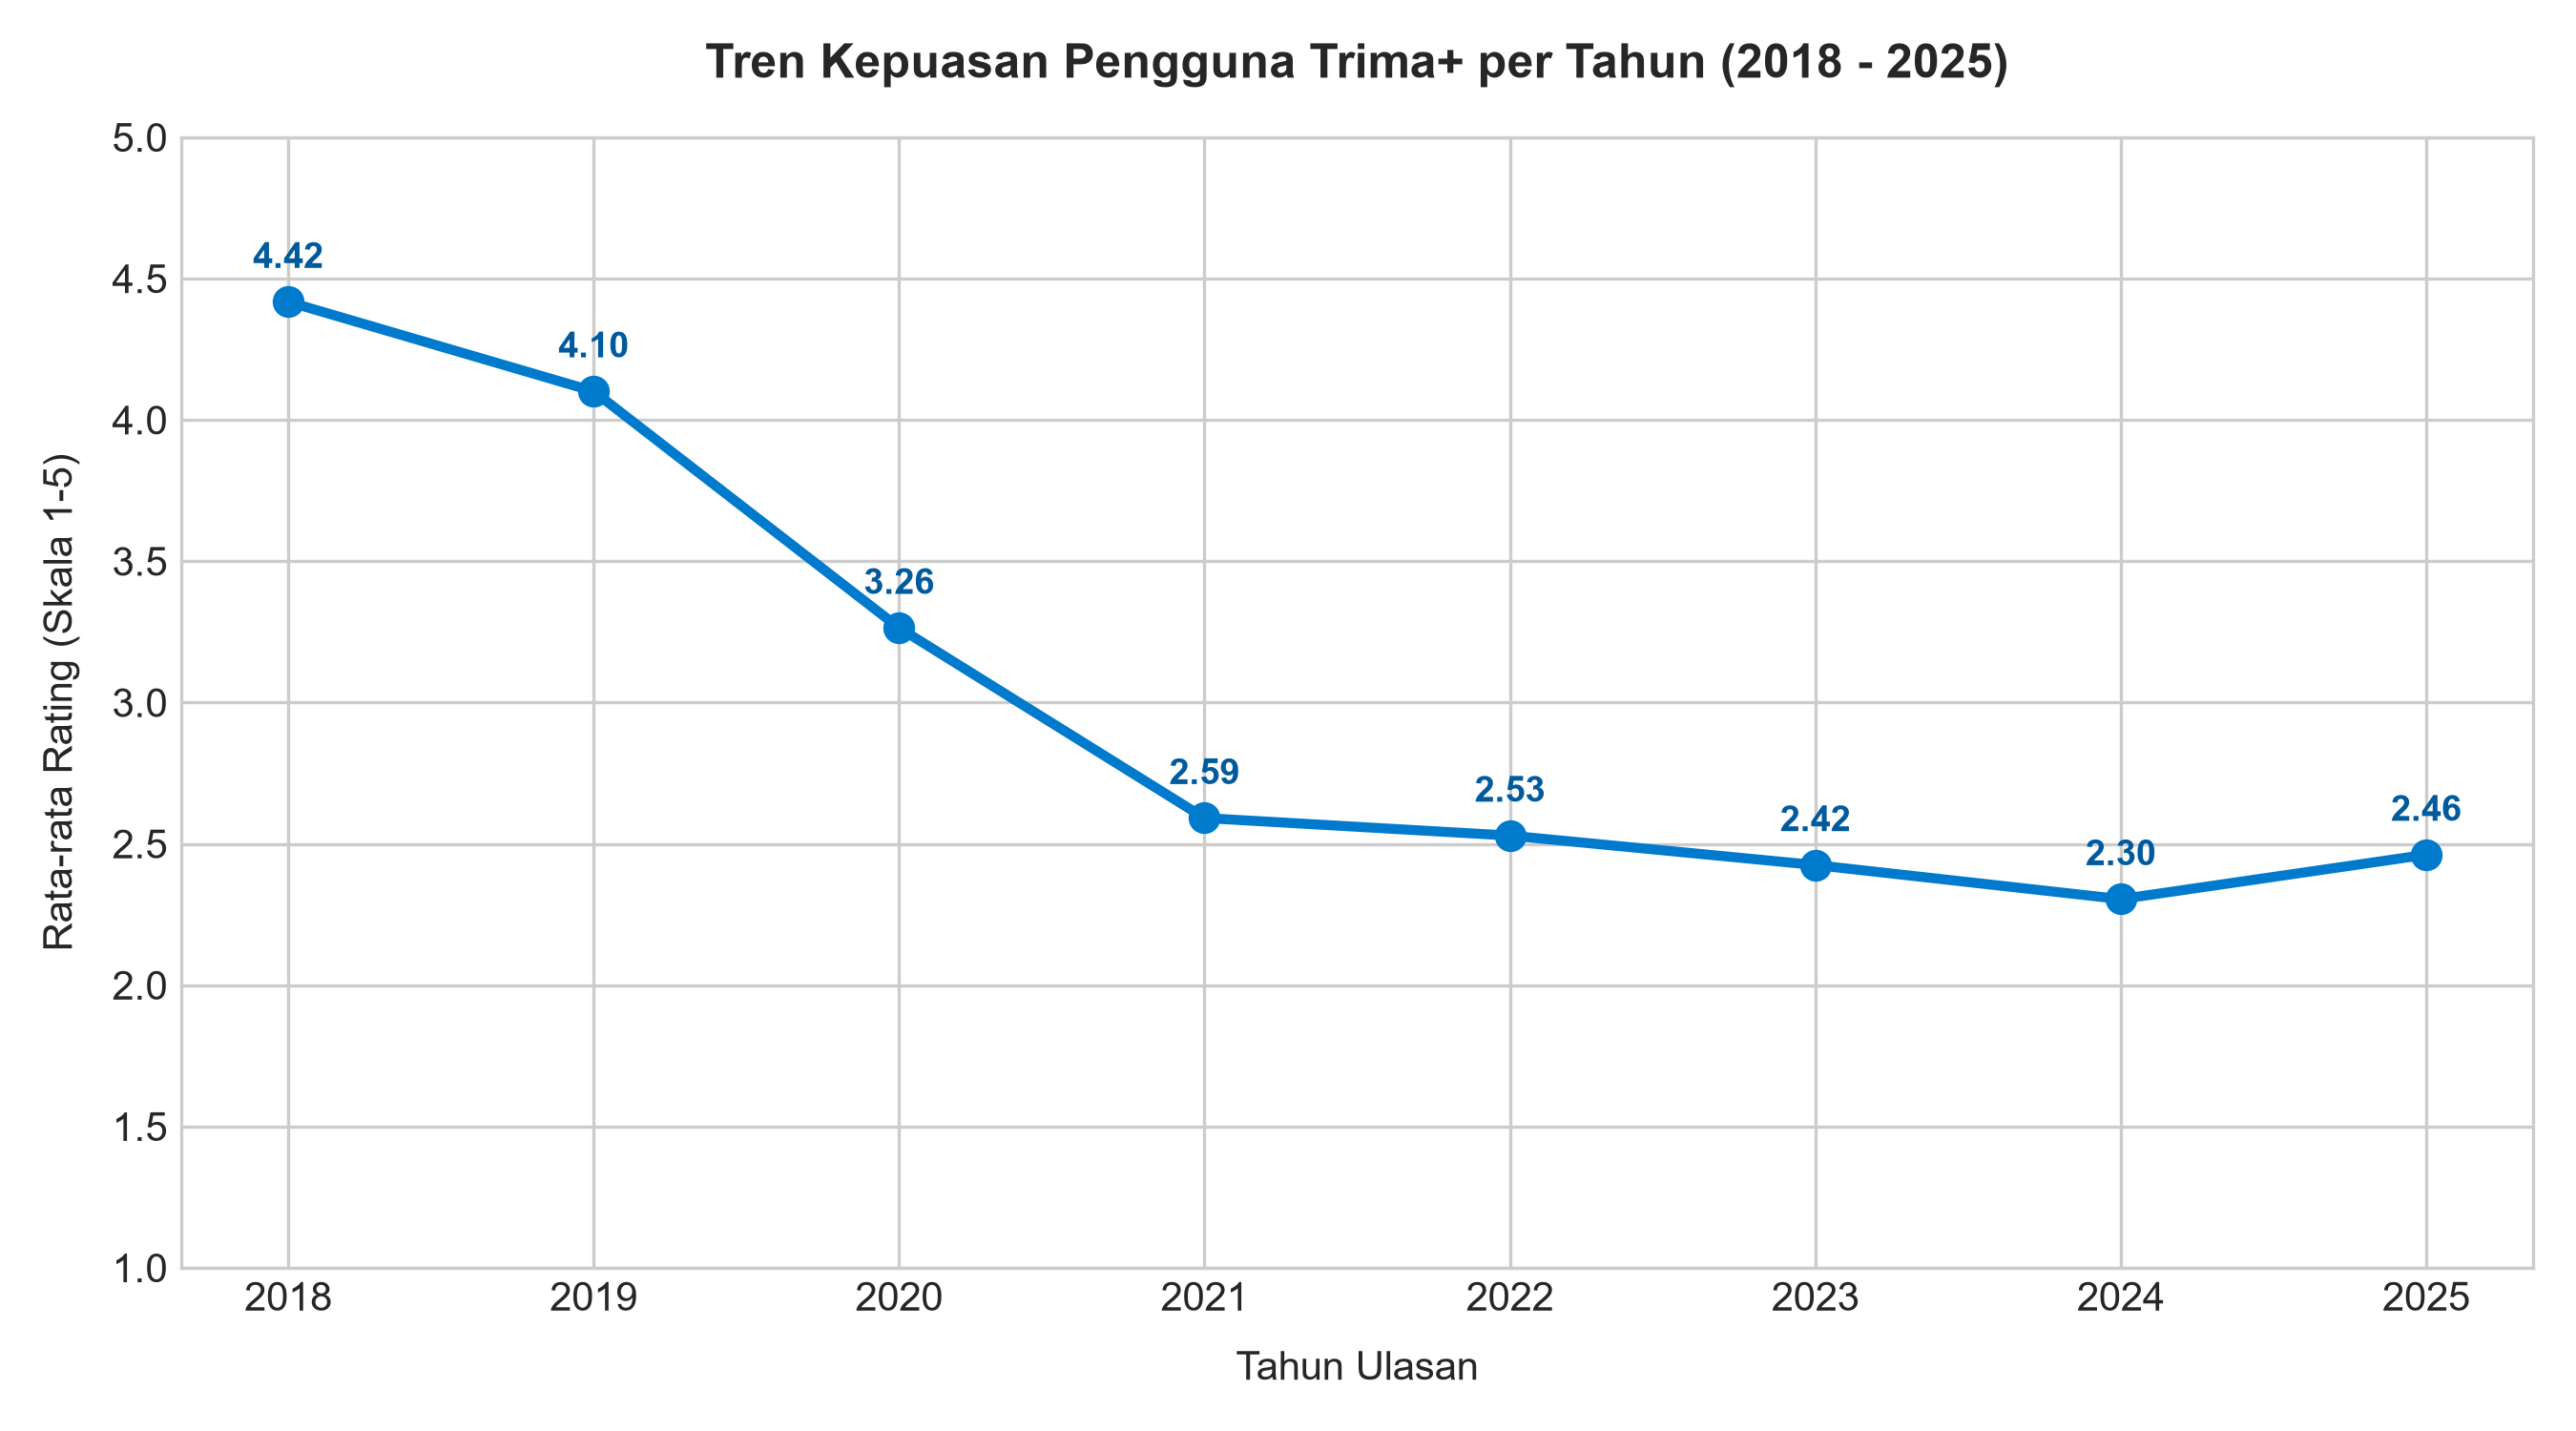

In [15]:
year_df = df[df['review_year'] != 'Unknown'].copy()
year_df['review_year'] = year_df['review_year'].astype(int)
year_df = year_df[year_df['review_year'] >= 2018]

trend_data = year_df.groupby('review_year').agg(
    avg_stars=('stars', 'mean'),
    total_reviews=('review_id', 'count'),
    neg_count=('stars', lambda s: (s <= 2).sum()),
    pos_count=('stars', lambda s: (s >= 4).sum())
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=150)
ax.plot(trend_data['review_year'], trend_data['avg_stars'], marker='o', color='#007acc', linewidth=2.5, markersize=7, label='Rata-rata Rating Bintang')
for x, y in zip(trend_data['review_year'], trend_data['avg_stars']):
    ax.text(x, y + 0.12, f"{y:.2f}", ha='center', fontsize=9, fontweight='bold', color='#005a9e')
    
ax.set_title("Tren Kepuasan Pengguna Trima+ per Tahun (2018 - 2025)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Tahun Ulasan", fontsize=10, labelpad=8)
ax.set_ylabel("Rata-rata Rating (Skala 1-5)", fontsize=10, labelpad=8)
ax.set_ylim(1.0, 5.0)
ax.set_xticks(trend_data['review_year'])
plt.show()

trend_data

## 8. Ringkasan Eksekutif & Temuan Kunci

### Q&A
* **Apakah tingginya proporsi bintang 5 (55.3%) harus diratakan atau dinormalisasi ke bawah?**
  Tidak. Jumlah bintang 5 yang mencapai 726 ulasan (55.3%) adalah temuan empiris otentik dari basis nasabah setia Trimegah yang mengapresiasi rekomendasi saham *Trima Picks* dan riset pasar. Normalisasi skor (0.6709 pada skala 0–1 dan 67.1 pada skala 0–100) diterapkan murni untuk standardisasi komparasi analitis, bukan memanipulasi distribusi data mentah.
* **Mengapa rata-rata rating review bertulis (3.68) berbeda dengan rating resmi Google Play (3.12)?**
  Karena angka 3.12 di Play Store dihitung dari seluruh 3.747 rating kumulatif (termasuk bintang tanpa ulasan teks), sedangkan angka 3.68 dihitung dari 1.312 ulasan publik yang memiliki teks. Pengguna yang meluangkan waktu menulis ulasan memiliki kecenderungan memberikan apresiasi fitur yang lebih mendalam dibanding sekadar menekan rating bintang secara instan.
* **Apa saja akar masalah utama yang ditemukan dari analisis seluruh kategori ulasan?**
  1. **Login & Autentikasi (143 ulasan / 98 negatif):** Auto-logout saat bursa buka jam 09:00 WIB, OTP terhambat, dan sinkronisasi sensor biometrik gagal.
  2. **UI/UX & Performa (104 ulasan / 58 negatif):** Bug regresi setelah update versi (aplikasi crash / blank screen pasca-update) dan navigasi yang berat.
  3. **Transaksi & Portofolio (66 ulasan / 34 negatif):** Penarikan dana (withdrawal) dari RDN ke rekening bank yang tertunda hingga berhari-hari.
  4. **Registrasi & KYC (29 ulasan / 19 negatif):** Validasi nomor telepon gagal dan upload foto KTP/wajah macet.
  5. **Fitur Analisis & Pasar (16 ulasan):** Absennya fitur *Automatic Stop Loss* dan kendala teknis pada grafik TradingView.

### Data Analysis Key Findings
- **Pola Distribusi Bimodal (U-Shaped):** Bintang 5 mendominasi dengan 55.3% (726 ulasan), namun Bintang 1 juga signifikan mencapai 21.5% (282 ulasan). Nasabah jarang berada di zona netral bintang 3 (8.8%), menunjukkan bahwa kepuasan aplikasi finansial bersifat biner: sangat puas atau sangat kecewa saat terjadi kendala teknis.
- **Negative Share Sebesar 28.4%:** Dari 1.312 ulasan, terdapat 372 ulasan bintang 1–2 yang mencerminkan risiko churn tinggi. Friksi pada jam perdagangan aktif langsung berakibat pada ulasan bintang 1 karena menyangkut potensi kerugian finansial investor ritel.
- **Developer Response Rate 48.0%:** Tim pengembang telah membalas 630 ulasan. Namun balasan masih menggunakan template standar. Perlu respon aktif pada isu kritis seperti penarikan dana RDN.

### Insights or Next Steps
- **Inisiatif 1: "Zero-Friction Authentication":** Lakukan perbaikan sistem *token refresh* latar belakang agar sesi pengguna tidak terputus di tengah jam perdagangan aktif dan integrasikan *biometric fallback* yang lebih stabil pasca-pembaruan sistem operasi.
- **Inisiatif 2: "Trima Lite Mode" & Fast Withdrawal:** Sediakan toggle antarmuka ringan khusus transaksi saham kilat (1-click buy/sell) dan percepat integrasi real-time API transfer RDN perbankan untuk mengeliminasi keluhan penarikan dana.